<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-2-swientyk/blob/main/UczenieMaszynowe_25_26_Lista2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.


## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

In [24]:
# wczytanie zbioru danych
titanic = pd.read_csv("/content/train.csv")

titanic.shape

(891, 12)

In [ ]:
titanic.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
titanic.drop(['PassengerId', 'Pclass', 'Survived'], axis=1).describe()

,Age,SibSp,Parch,Fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


## Przekształcenie danych

In [25]:
ranges = [0, 12, 18, 35, 50, 65, float('inf')]
age_group = ['Children (<12)', 'Teenagers (12-18)', 'Young adults (18-35)', 'Adults (35-50)', 'Older adults (50-65)', 'Seniors (>65)']
titanic['AgeGroup'] = pd.cut(titanic['Age'], bins=ranges, labels=age_group)
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Young adults (18-35)
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adults (35-50)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young adults (18-35)
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Young adults (18-35)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Young adults (18-35)


In [26]:
titanic['HasCabin'] = titanic['Cabin'].notna().astype(int)
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Young adults (18-35),0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adults (35-50),1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young adults (18-35),0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Young adults (18-35),1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Young adults (18-35),0


In [27]:
sex_mask = titanic['Sex'] == 'male'
titanic.loc[sex_mask, 'Sex'] = 0
titanic.loc[~sex_mask, 'Sex'] = 1
titanic['Sex'] = titanic['Sex'].astype(int)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,Young adults (18-35),0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,Adults (35-50),1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young adults (18-35),0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,Young adults (18-35),1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,Young adults (18-35),0


## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.

### Wiek pasażera

In [28]:
age_median = titanic['Age'].median()
titanic['Age'] = titanic['Age'].fillna(age_median)

In [ ]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"


### Zaokrętowanie

In [29]:
titanic.dropna(subset=['Embarked'], inplace=True)

In [ ]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

cabin class-corelation table:
          HasCabin    Pclass      Fare
HasCabin  1.000000 -0.723815  0.480425
Pclass   -0.723815  1.000000 -0.548193
Fare      0.480425 -0.548193  1.000000


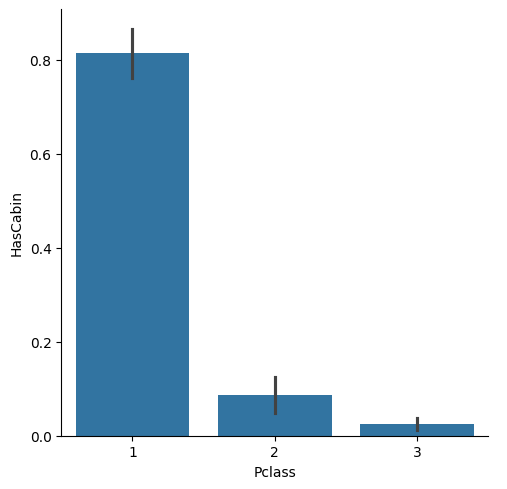

In [30]:
cabin_class_corelation = titanic[['HasCabin', 'Pclass', 'Fare']].corr()
print("cabin class-corelation table:")
print(cabin_class_corelation)
sns.catplot(x="Pclass", y="HasCabin", data=titanic, kind="bar")

In [31]:
titanic = titanic.drop('Cabin', axis=1)
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,Young adults (18-35),0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,Adults (35-50),1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,Young adults (18-35),0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,Young adults (18-35),1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,Young adults (18-35),0


In [ ]:
# assert titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [ ]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

In [20]:
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,Young adults (18-35),0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,Adults (35-50),1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,Young adults (18-35),0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,Young adults (18-35),1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,Young adults (18-35),0


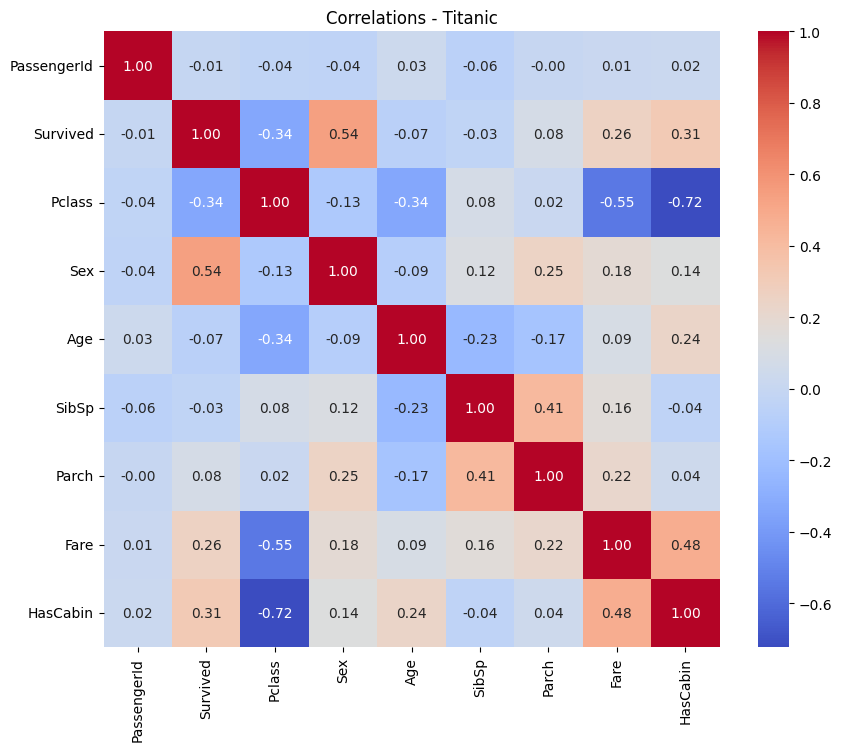

In [32]:
numeric_data_titanic = titanic.select_dtypes(include=['float64', 'int64', 'bool'])
corr_matrix_titanic = numeric_data_titanic.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(data=corr_matrix_titanic, annot=True, cmap='coolwarm', fmt=".2f", square=True)

plt.title('Correlations - Titanic')
plt.show()

Text(0.5, 1.0, 'Survival rate of passengers by class and sex')

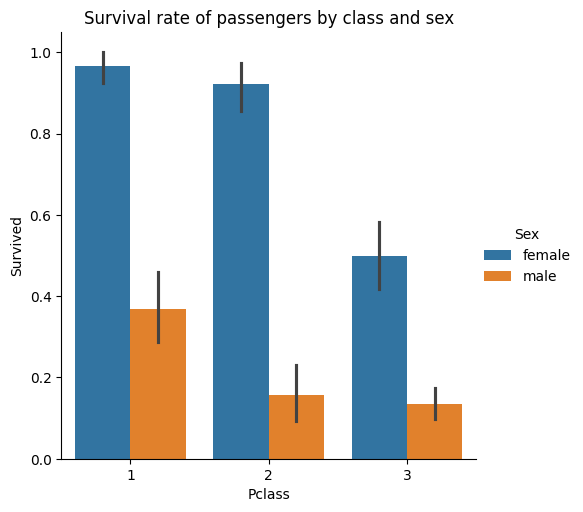

In [ ]:
sns.catplot(x="Pclass", y="Survived", hue="Sex", data=titanic, kind="bar")
plt.title('Survival rate of passengers by class and sex')

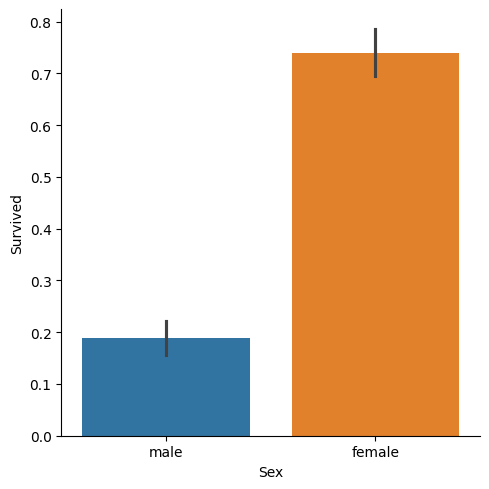

In [ ]:
sns.catplot(x="Sex", y="Survived", hue="Sex", data=titanic, kind="bar")

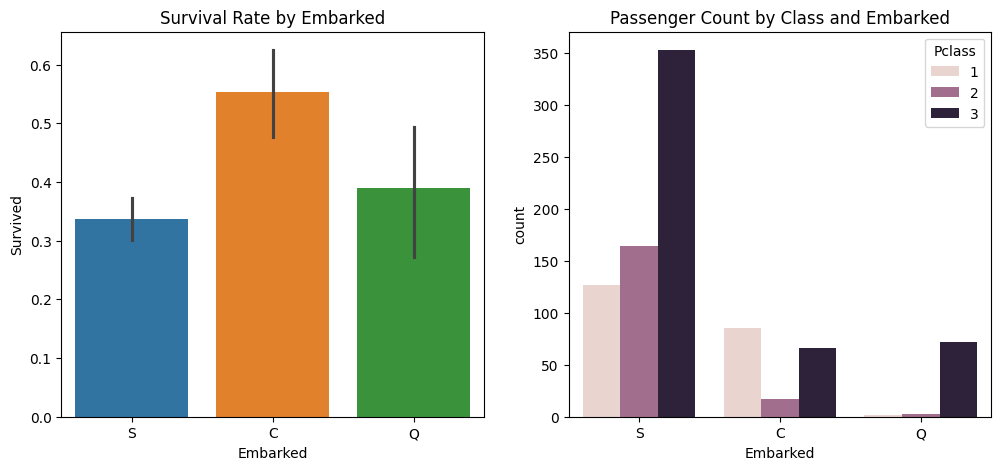

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x="Embarked", y="Survived", hue="Embarked", data=titanic, ax=axes[0])
axes[0].set_title("Survival Rate by Embarked")

sns.countplot(x="Embarked", hue="Pclass", data=titanic, ax=axes[1])
axes[1].set_title("Passenger Count by Class and Embarked")

plt.show()

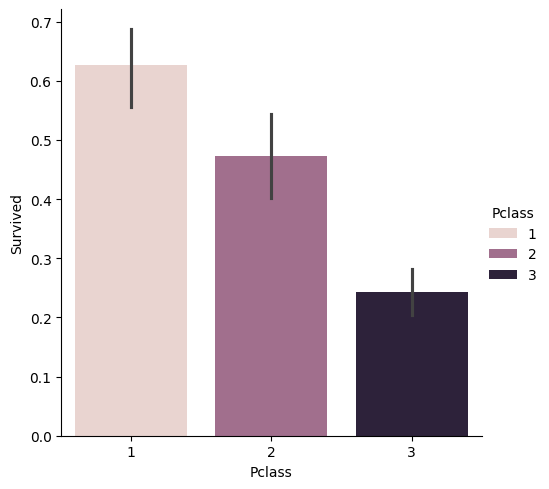

In [ ]:
sns.catplot(x="Pclass", y="Survived", hue="Pclass", data=titanic, kind="bar")

([], [])

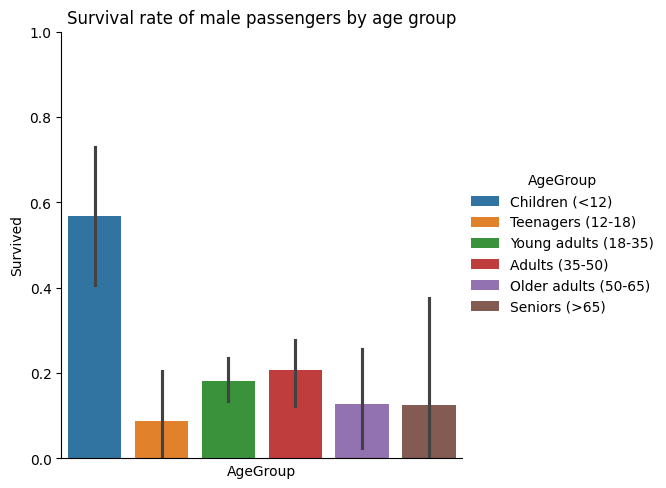

In [ ]:
gm = sns.catplot(x="AgeGroup", y="Survived", hue='AgeGroup', data=titanic[titanic['Sex'] == 'male'], kind="bar")
gm.set(ylim=(0, 1))
plt.title('Survival rate of male passengers by age group')
plt.xticks([])

([], [])

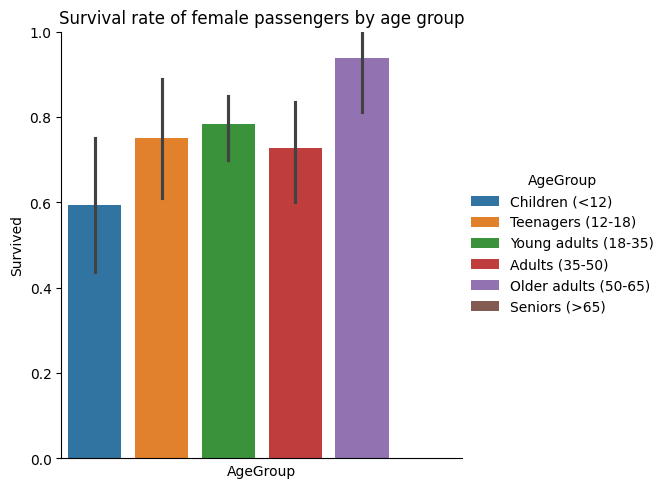

In [ ]:
gf = sns.catplot(x="AgeGroup", y="Survived", hue='AgeGroup', data=titanic[titanic['Sex'] == 'female'], kind="bar")
gf.set(ylim=(0, 1))
plt.title('Survival rate of female passengers by age group')
plt.xticks([])

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

-------------------------------------------------------------------------------
Analizując powyższe dane można zauważyć, że największe szansę na przeżycie miały kobiety podróżujące pierwszą klasą. Cechy, które wyraźnie decydowały o szansie na przeżycie to płeć, klasa biletu, oraz wiek pasażerów. Jest też kilka atrybutów które są ze sobą na tyle skorleowane, że nie biorę ich pod uwagę osobno - klasa biletu, cena biletu, oraz kabiny. Wśród mężczyzn, u których szansa na przeżycie wynosiła około 20% (przy czym dla mężczyzn podróżujących pierwszą klasą, ta sznasa była prawie dwa razy większa) znacznie wybijają się dzieci do 12 lat, których szansa wynosi okło 60%, czyli tyle ile dla dziewczynek w tym przedziale wiekowym.

-------------------------------------------------------------------------------

# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

In [ ]:
spotify = pd.read_csv("/content/dataset.csv")

spotify.shape

(114000, 21)

In [ ]:
spotify.head(10)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


In [ ]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
spotify.drop(['Unnamed: 0', 'mode'], axis=1).describe()

,popularity,duration_ms,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Przekształcenia i filtracja danych

In [ ]:
spotify['explicit'] = spotify['explicit'].astype(int)

## Wizualizacje

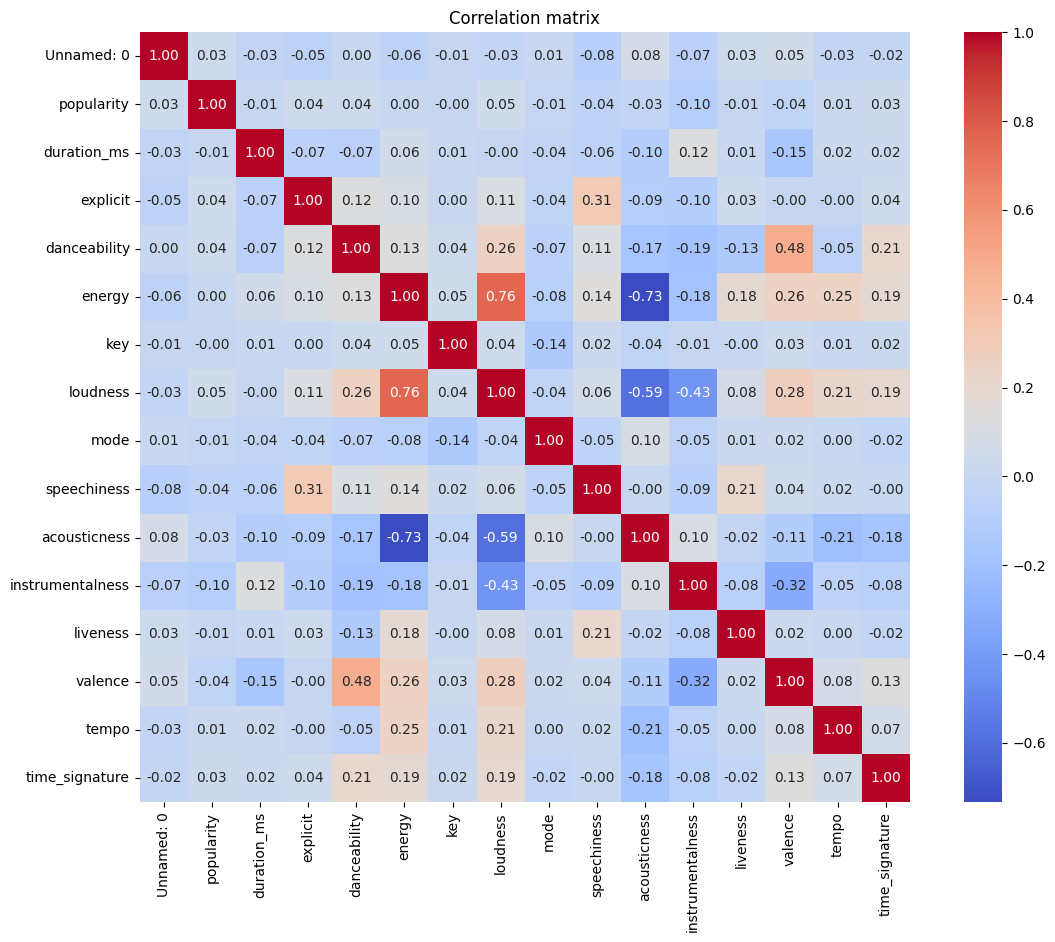

In [ ]:
numeric_data = spotify.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation matrix')
plt.show()

/tmp/ipykernel_14563/2463761110.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=spotify, x='explicit', y='energy', palette='Set2')


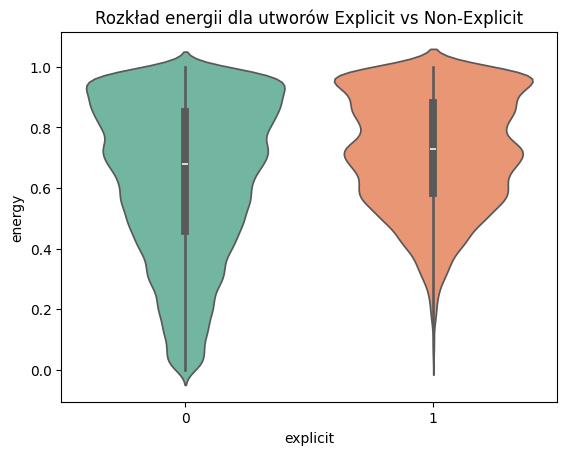

In [ ]:
sns.violinplot(data=spotify, x='explicit', y='energy', palette='Set2')
plt.title('Rozkład energii dla utworów Explicit vs Non-Explicit')
plt.show()

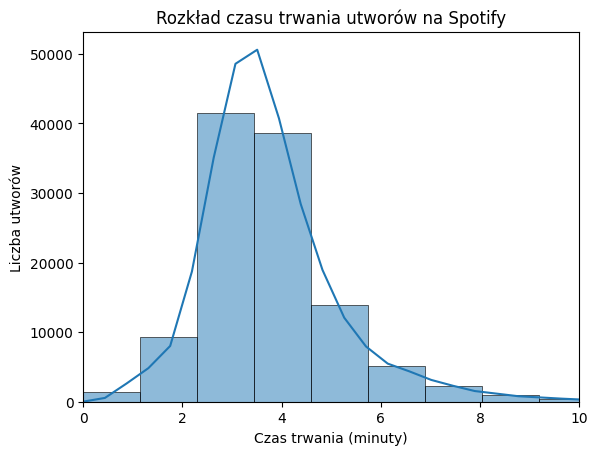

In [ ]:
spotify['duration_min'] = spotify['duration_ms'] / 60000

sns.histplot(data=spotify, x='duration_min', bins=76, kde=True)

plt.title('Rozkład czasu trwania utworów na Spotify')
plt.xlabel('Czas trwania (minuty)')
plt.ylabel('Liczba utworów')
plt.xlim(0, 10)
plt.show()

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [ ]:
# dla ułatwienia - gotowe słowniki

key_map = {-1: np.nan, 0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}
mode_map = {0: 'Minor', 1: 'Major'}
emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [ ]:
spotify['key_mapped'] = spotify['key'].map(key_map)
spotify['mode_mapped'] = spotify['mode'].map(mode_map)
print(spotify[['key_mapped', 'mode_mapped']].head())
spotify['key_mapped'].info() #nie ma pustych wartości w kluczu

  key_mapped mode_mapped
0         C#       Minor
1         C#       Major
2          C       Major
3          C       Major
4          D       Major
<class 'pandas.core.series.Series'>
RangeIndex: 114000 entries, 0 to 113999
Series name: key_mapped
Non-Null Count   Dtype 
--------------   ----- 
114000 non-null  object
dtypes: object(1)
memory usage: 890.8+ KB


In [ ]:
spotify['emotion'] = [(k, m) for k, m in zip(spotify['key_mapped'], spotify['mode_mapped'])]
spotify['emotion'] = spotify['emotion'].map(emotion_map)
spotify.head(3)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,key_mapped,mode_mapped,emotion
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.461,...,0.0322,0.000001,0.358,0.715,87.917,4,acoustic,C#,Minor,Melancholic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.166,...,0.9240,0.000006,0.101,0.267,77.489,4,acoustic,C#,Major,Joyful
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.359,...,0.2100,0.000000,0.117,0.120,76.332,4,acoustic,C,Major,Happy


## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji



### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [ ]:
spotify_filtered = spotify.drop(columns=['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'key_mapped',	'mode_mapped',	'emotion', 'loudness', 'acousticness'])

### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    # print(f"Features  : {features}")
    # print(f"Test Acc  : {acc:.4f}")
    return acc

In [ ]:
# WYWOŁAJ KLASYFIKATOR W TYM MIEJSCU
example_feats = ["duration_ms", "explicit", "danceability", "energy","key", "loudness", "mode", "speechiness", "acousticness","instrumentalness", "liveness", "valence", "tempo", "time_signature"]
base_acc = classify(spotify, example_feats)
print(f"All Features  : {example_feats}")
print(f"Base Acc  : {base_acc:.4f}")

import itertools

accuracies = {}
for drop_number in range(1, 3):
    for to_drop in itertools.combinations(example_feats, drop_number):
        new_features = [c for c in example_feats if c not in to_drop]

        test_result = classify(spotify, new_features)
        new_features = (tuple)(new_features)
        accuracies[new_features] = test_result

best_features = max(accuracies, key=accuracies.get)
best_acc = accuracies[best_features]

print(f"Best Acc: {best_acc:.4f}")
print(f"Best_features: {best_features}")


All Features  : ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Base Acc  : 0.6214
Best Acc: 0.6284
Best_features: ('duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'time_signature')


### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import preprocessing

In [ ]:
# przykładowe funkcje

def dataframe_xy(df):
    raise NotImplementedError()
    return X, y

# normalize to [0,1] range
def normalize(X):
    raise NotImplementedError()

# standarize (e.g, w/ scikit standard scaler)
def standarize(X):
    raise NotImplementedError()

# remove outliers
def remove_outliers(X, y):
    raise NotImplementedError()
